<a href="https://colab.research.google.com/github/devikarajeev770-afk/AI-ML-Course/blob/main/Random_forest_algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## What is Random Forest algorithm?

Random forest is a machine learning algorithm that is used for both classification and regression tasks. It is an ensemble learning method that combines multiple decision trees to create a powerful model.

## Advantages of RF- reduce over-fitting

In a random forest, a large number of decision trees are built using random subsets of the training data and random subsets of the features. Each decision tree in the forest is built independently of the others, which helps to reduce the risk of overfitting.

## How it works?
When a new instance is to be classified or predicted, it is passed through all the decision trees in the forest, and the majority vote or average of the predictions of each tree is taken as the final prediction of the random forest model.

Random forest algorithm is connected to decision trees as it is built using multiple decision trees. Each decision tree is a model that is built by recursively splitting the data based on the most significant feature. The goal is to create a tree-like model of decisions that can predict the target variable based on the values of the input variables.

However, decision trees can be prone to overfitting, meaning that they may perform well on the training data but not generalize well to new data. Random forest algorithm addresses this problem by building multiple decision trees using random subsets of the data and random subsets of the features. This randomness helps to reduce the variance of the model and increase its robustness.

## Example-1 Classification of Iris data set

### Loading the libraries

In [ ]:
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

### Loading the dataset from `sklearn` & create test-train split

In [ ]:
iris = load_iris()
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.3, random_state=43)

### Creating the estimator

In [ ]:
# Initialize the random forest classifier with 3 trees
rf = RandomForestClassifier(n_estimators=5, random_state=43)

### `fit-predict-score` sequence

In [ ]:
# Train the random forest classifier on the training data
rf.fit(X_train, y_train)

# Use the trained random forest classifier to make predictions on the test data
predictions = rf.predict(X_test)

# Evaluate the accuracy of the random forest classifier on the test data
accuracy = rf.score(X_test, y_test)

In [ ]:
print("Predictions:", predictions)
print("Accuracy:", accuracy)

Predictions: [0 0 2 1 2 0 2 1 1 1 0 1 2 0 1 1 0 0 2 2 0 0 0 2 2 2 0 1 0 0 1 0 1 1 2 2 1
 2 1 1 1 2 1 2 0]
Accuracy: 0.9777777777777777


## Plotting trees in the forest

In [ ]:
from sklearn.tree import export_graphviz
import pydot

In [ ]:
# Extract the individual trees from the random forest
estimators = rf.estimators_

# Visualize each decision tree in the random forest
for i in range(len(estimators)):
    tree = estimators[i]
    export_graphviz(tree, out_file='tree.dot',
                    feature_names=iris.feature_names,
                    class_names=iris.target_names,
                    rounded=True, proportion=False,
                    precision=2, filled=True)
    (graph,) = pydot.graph_from_dot_file('tree.dot')
    graph.write_png(f'tree_{i}.png')

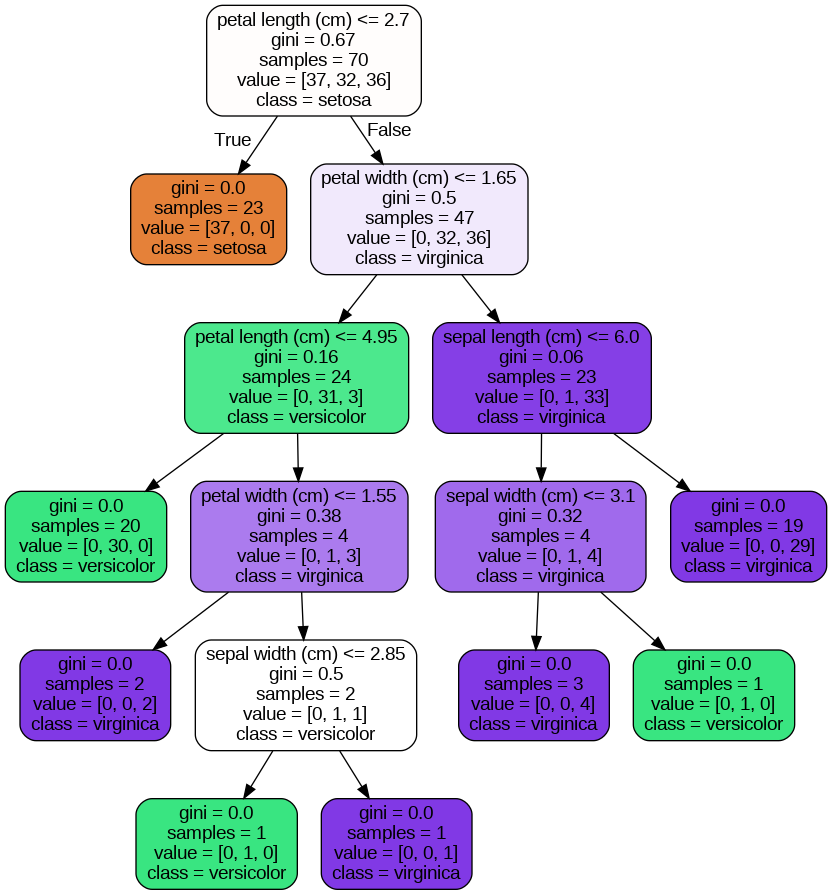

In [ ]:
from IPython.display import Image
Image('/content/tree_0.png')

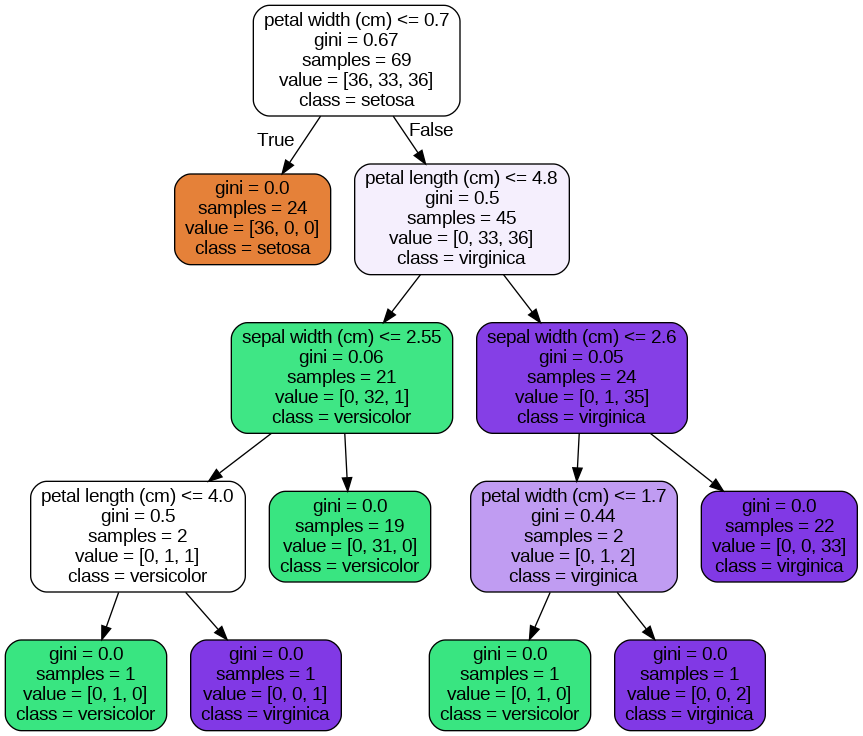

In [ ]:
Image('/content/tree_1.png')

## Example-2 MNIST classification using RF

In [ ]:
#loading necessary libraries
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
%matplotlib inline
# loading dataset from sklern.datasets
mnist = load_digits()

In [ ]:
mnist.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [ ]:
pd.DataFrame(mnist.data).head()

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


In [ ]:
pd.DataFrame(mnist.target).head()

,0
0,0
1,1
2,2
3,3
4,4


In [ ]:
# display image dimension
np.shape(mnist.images[1])

(8, 8)

In [ ]:
#showing the pixel values in the first image
mnist.images[0]

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

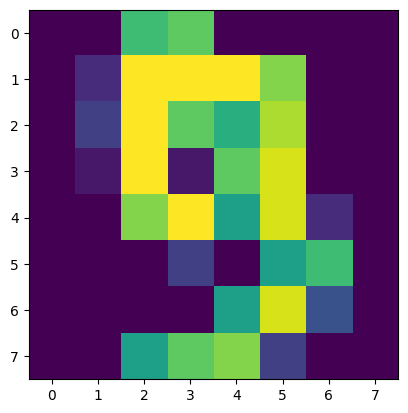

In [ ]:
# displaying the two dimensional array as an image
plt.imshow(mnist.images[9]);

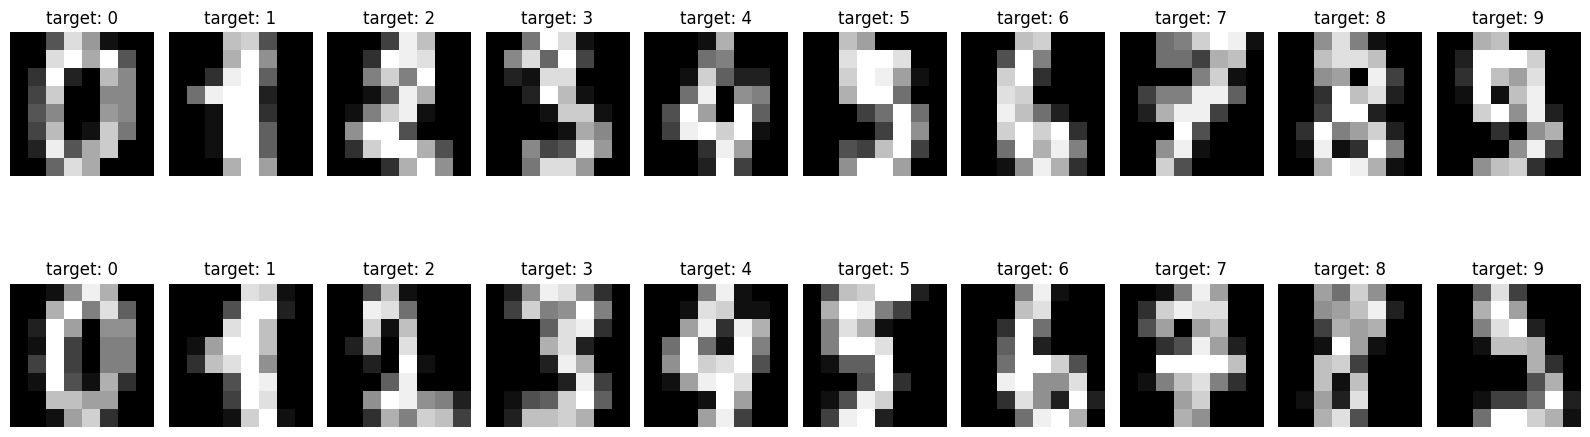

In [ ]:
fig, axes = plt.subplots(2, 10, figsize=(16, 6))
for i in range(20):
    axes[i//10, i %10].imshow(mnist.images[i], cmap='gray');
    axes[i//10, i %10].axis('off')
    axes[i//10, i %10].set_title(f"target: {mnist.target[i]}")

plt.tight_layout()

## Machine learning part

In [ ]:
# Split the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(mnist.data, mnist.target,train_size=0.55, test_size=0.45,random_state=43)

In [ ]:
# Train a Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=40, random_state=42)
rf_classifier.fit(X_train, y_train)

RandomForestClassifier(n_estimators=40, random_state=42)

In [ ]:
# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

In [ ]:
# Evaluate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9728059332509271
